Doğruluk Oranı: 81.42%
Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.85      0.93      0.89       408
           1       0.53      0.33      0.41        98

    accuracy                           0.81       506
   macro avg       0.69      0.63      0.65       506
weighted avg       0.79      0.81      0.80       506



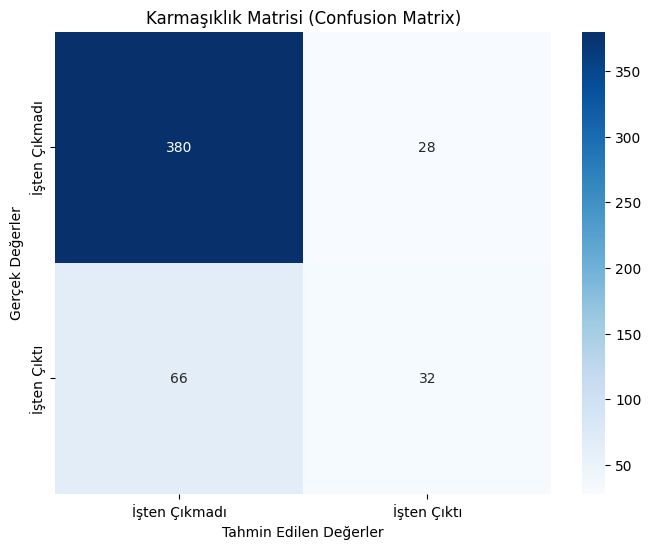

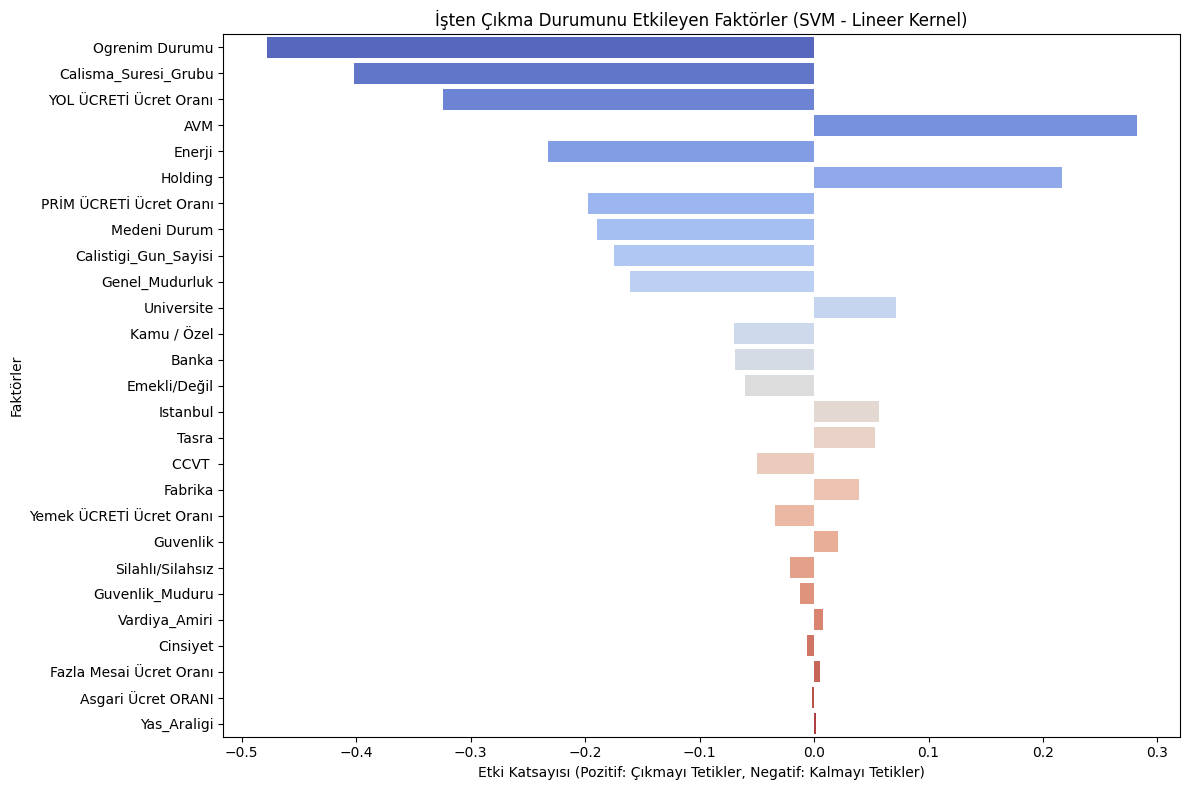

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Veriyi yükleme
# Kopyaladığın yolu tırnakların içine yapıştır. 
# Başına 'r' harfi koymayı unutma, bu Windows'taki ters eğik çizgilerin (\) hata vermesini engeller.
df = pd.read_excel(r"C:\Users\enesa\Downloads\22nisanverileri.xlsx")

# Özellikler (ilk 27 sütun) ve Hedef (28. sütun olan İşten Çıkma Durumu)
X = df.iloc[:, :27]
y = df.iloc[:, 27]
feature_names = X.columns

# Veriyi Eğitim (%80) ve Test (%20) setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SVM modelleri ölçeklendirmeye duyarlı olduğu için veriyi standartlaştırıyoruz
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelin hangi faktörlerden ne kadar etkilendiğini görebilmek için Linear Kernel kullanıyoruz
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Tahmin yapma ve doğruluğu hesaplama
y_pred = svm_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Doğruluk Oranı: {accuracy * 100:.2f}%")
print("Sınıflandırma Raporu:\n", classification_report(y_test, y_pred))

# Grafik 1: Karmaşıklık Matrisi (Confusion Matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['İşten Çıkmadı', 'İşten Çıktı'], 
            yticklabels=['İşten Çıkmadı', 'İşten Çıktı'])
plt.title('Karmaşıklık Matrisi (Confusion Matrix)')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilen Değerler')
plt.show()

# Grafik 2: Özellik Önem Dereceleri (Feature Importances)
importances = svm_model.coef_[0]
feature_importance_df = pd.DataFrame({'Faktör': feature_names, 'Etki (Ağırlık)': importances})

# En çok etki edenleri üste almak için mutlak değere göre sıralama
feature_importance_df['Mutlak_Etki'] = feature_importance_df['Etki (Ağırlık)'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Mutlak_Etki', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Etki (Ağırlık)', y='Faktör', data=feature_importance_df, hue='Faktör', palette='coolwarm', legend=False)
plt.title('İşten Çıkma Durumunu Etkileyen Faktörler (SVM - Lineer Kernel)')
plt.xlabel('Etki Katsayısı (Pozitif: Çıkmayı Tetikler, Negatif: Kalmayı Tetikler)')
plt.ylabel('Faktörler')
plt.tight_layout()
plt.show()

Model eğitiliyor ve en iyi parametreler aranıyor... (Bu biraz sürebilir)
Bulunan En İyi Parametre: {'svm__C': 1}

Güncellenmiş Doğruluk Oranı: 71.94%
Yeni Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.92      0.71      0.80       408
           1       0.38      0.74      0.51        98

    accuracy                           0.72       506
   macro avg       0.65      0.73      0.66       506
weighted avg       0.82      0.72      0.75       506



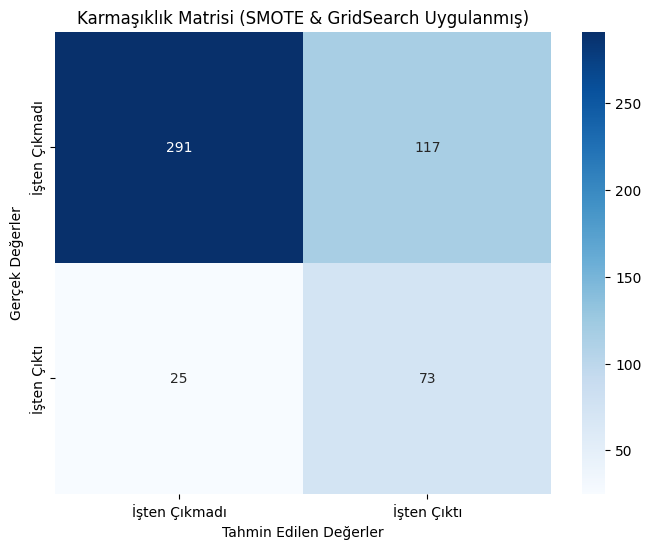

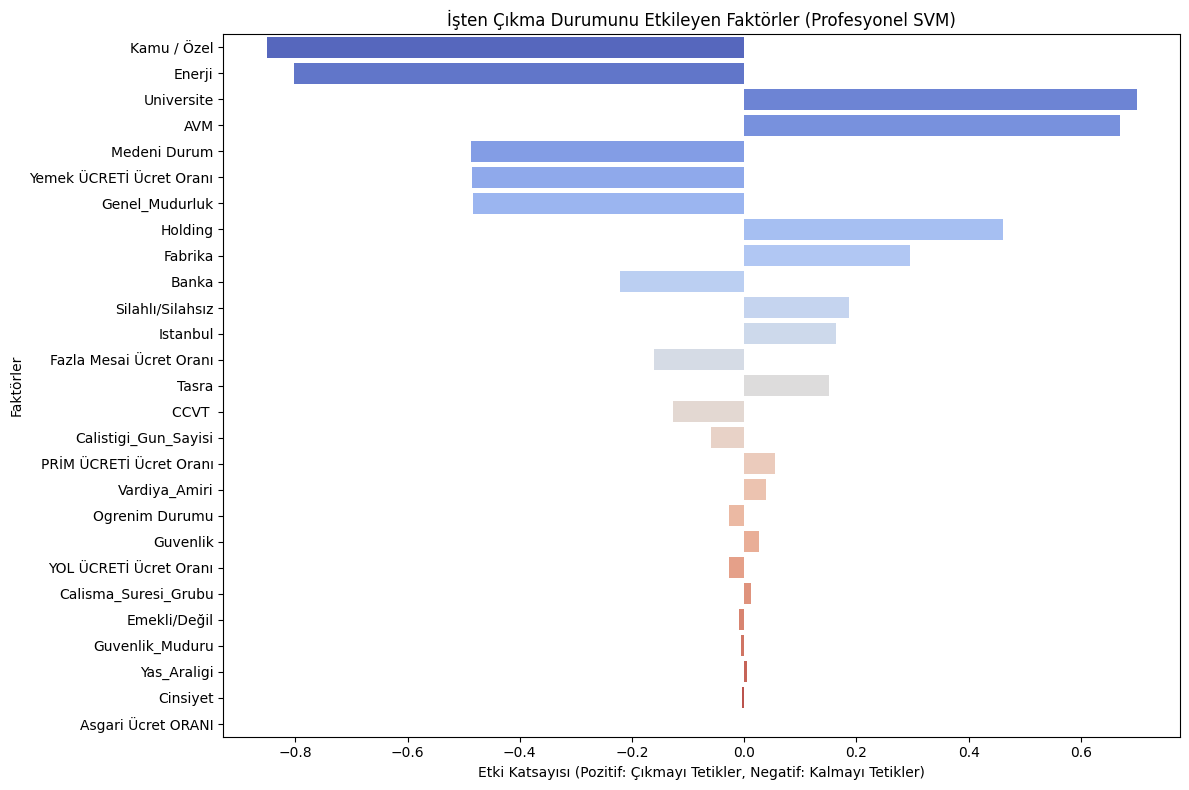

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline # Normal Pipeline yerine imblearn pipeline kullanıyoruz (Veri sızıntısını önler)

# 1. Veriyi Yükleme (Dosya yolunu kendi bilgisayarına göre güncelle)
df = pd.read_excel(r"C:\Users\enesa\Downloads\22nisanverileri.xlsx")

# Özellikler ve Hedef
X = df.iloc[:, :27]
y = df.iloc[:, 27]
feature_names = X.columns

# 2. Katmanlı Bölme (Stratify): Test ve eğitim setlerindeki işten çıkma oranının aynı kalmasını sağlar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Profesyonel Pipeline Kurulumu
# İşlem sırası: Önce veriyi standartlaştır -> Sonra az olan sınıfı SMOTE ile çoğalt -> Sonra SVM'i eğit
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(kernel='linear', random_state=42))
])

# 4. Hiperparametre Optimizasyonu (Grid Search)
# SVM'in 'C' parametresi için en iyi değeri arıyoruz. (Bu işlem bilgisayarı biraz daha yoracaktır, hoca haklı!)
param_grid = {
    'svm__C': [0.1, 1, 10] # En iyi esneklik ayarını bulması için 3 farklı senaryo deneyecek
}

# Modeli 5-Fold Cross Validation ile eğitiyoruz (scoring='f1' ile azınlık sınıfı yakalamaya odaklanıyoruz)
print("Model eğitiliyor ve en iyi parametreler aranıyor... (Bu biraz sürebilir)")
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Bulunan En İyi Parametre: {grid_search.best_params_}")

# 5. En İyi Model ile Tahmin ve Raporlama
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nGüncellenmiş Doğruluk Oranı: {accuracy * 100:.2f}%")
print("Yeni Sınıflandırma Raporu:\n", classification_report(y_test, y_pred))

# Grafik 1: Karmaşıklık Matrisi
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['İşten Çıkmadı', 'İşten Çıktı'], 
            yticklabels=['İşten Çıkmadı', 'İşten Çıktı'])
plt.title('Karmaşıklık Matrisi (SMOTE & GridSearch Uygulanmış)')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilen Değerler')
plt.show()

# Grafik 2: Özellik Önem Dereceleri (Pipeline içindeki SVM modelinden ağırlıkları çekiyoruz)
importances = best_model.named_steps['svm'].coef_[0]
feature_importance_df = pd.DataFrame({'Faktör': feature_names, 'Etki (Ağırlık)': importances})

feature_importance_df['Mutlak_Etki'] = feature_importance_df['Etki (Ağırlık)'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Mutlak_Etki', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Etki (Ağırlık)', y='Faktör', data=feature_importance_df, hue='Faktör', palette='coolwarm', legend=False)
plt.title('İşten Çıkma Durumunu Etkileyen Faktörler (Profesyonel SVM)')
plt.xlabel('Etki Katsayısı (Pozitif: Çıkmayı Tetikler, Negatif: Kalmayı Tetikler)')
plt.ylabel('Faktörler')
plt.tight_layout()
plt.show()

Doğruluk Oranı: 83.42%
Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.85      0.93      0.89       421
           1       0.77      0.60      0.68       170

    accuracy                           0.83       591
   macro avg       0.81      0.76      0.78       591
weighted avg       0.83      0.83      0.83       591



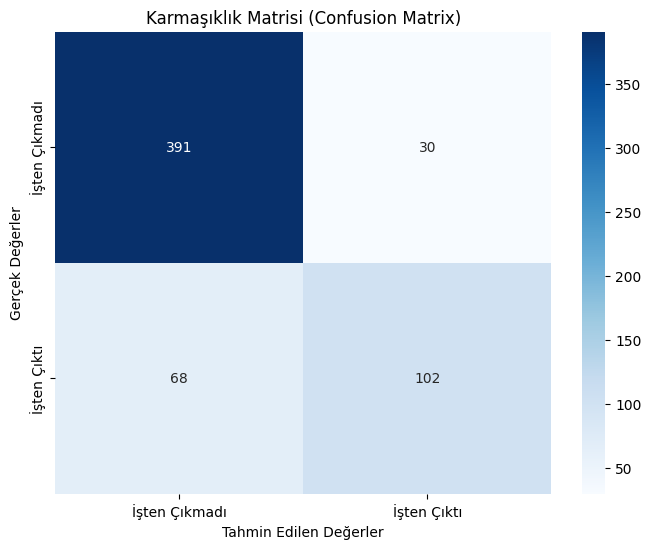

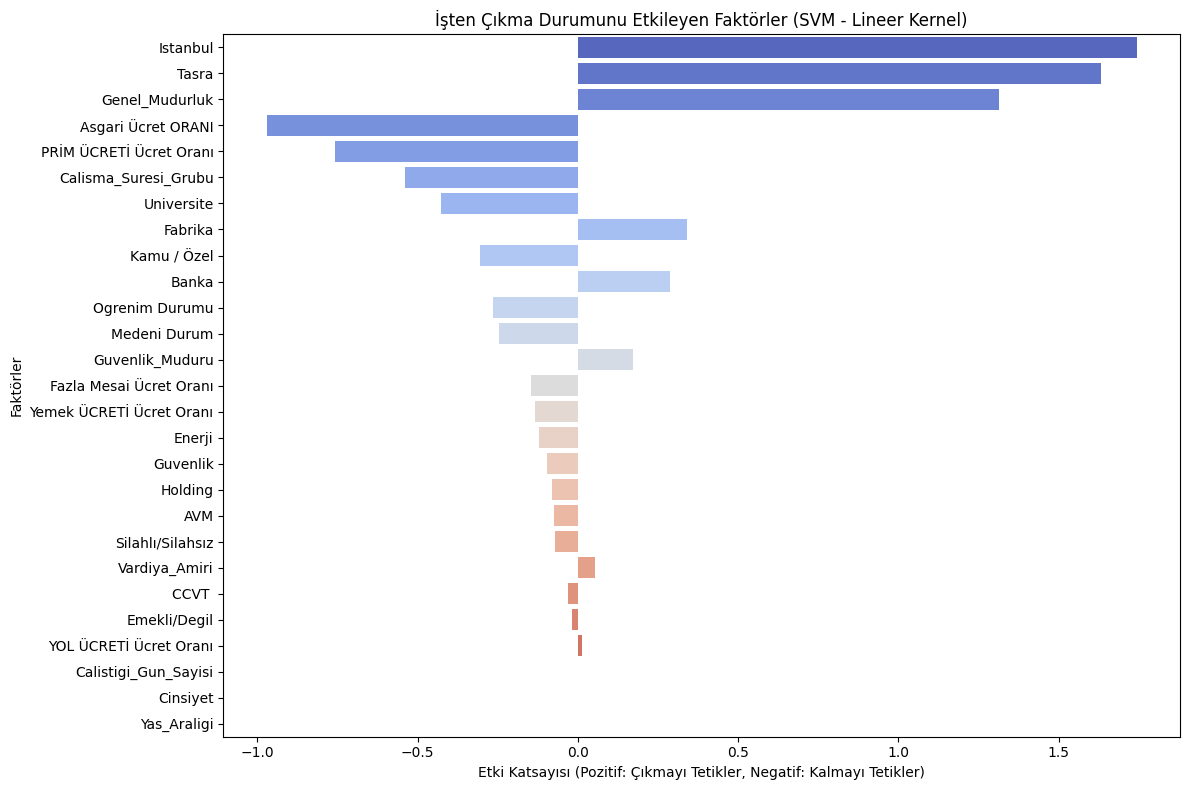

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Veriyi yükleme
# Kopyaladığın yolu tırnakların içine yapıştır. 
# Başına 'r' harfi koymayı unutma, bu Windows'taki ters eğik çizgilerin (\) hata vermesini engeller.
df = pd.read_excel(r"C:\Users\enesa\Downloads\3binlikveri.xlsx")

# Özellikler (ilk 27 sütun) ve Hedef (28. sütun olan İşten Çıkma Durumu)
X = df.iloc[:, :27]
y = df.iloc[:, 27]
feature_names = X.columns

# Veriyi Eğitim (%80) ve Test (%20) setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SVM modelleri ölçeklendirmeye duyarlı olduğu için veriyi standartlaştırıyoruz
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelin hangi faktörlerden ne kadar etkilendiğini görebilmek için Linear Kernel kullanıyoruz
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Tahmin yapma ve doğruluğu hesaplama
y_pred = svm_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Doğruluk Oranı: {accuracy * 100:.2f}%")
print("Sınıflandırma Raporu:\n", classification_report(y_test, y_pred))

# Grafik 1: Karmaşıklık Matrisi (Confusion Matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['İşten Çıkmadı', 'İşten Çıktı'], 
            yticklabels=['İşten Çıkmadı', 'İşten Çıktı'])
plt.title('Karmaşıklık Matrisi (Confusion Matrix)')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilen Değerler')
plt.show()

# Grafik 2: Özellik Önem Dereceleri (Feature Importances)
importances = svm_model.coef_[0]
feature_importance_df = pd.DataFrame({'Faktör': feature_names, 'Etki (Ağırlık)': importances})

# En çok etki edenleri üste almak için mutlak değere göre sıralama
feature_importance_df['Mutlak_Etki'] = feature_importance_df['Etki (Ağırlık)'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Mutlak_Etki', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Etki (Ağırlık)', y='Faktör', data=feature_importance_df, hue='Faktör', palette='coolwarm', legend=False)
plt.title('İşten Çıkma Durumunu Etkileyen Faktörler (SVM - Lineer Kernel)')
plt.xlabel('Etki Katsayısı (Pozitif: Çıkmayı Tetikler, Negatif: Kalmayı Tetikler)')
plt.ylabel('Faktörler')
plt.tight_layout()
plt.show()

Eski veri (2500 satır) eğitiliyor...
Yeni veri (3000 satır) eğitiliyor...


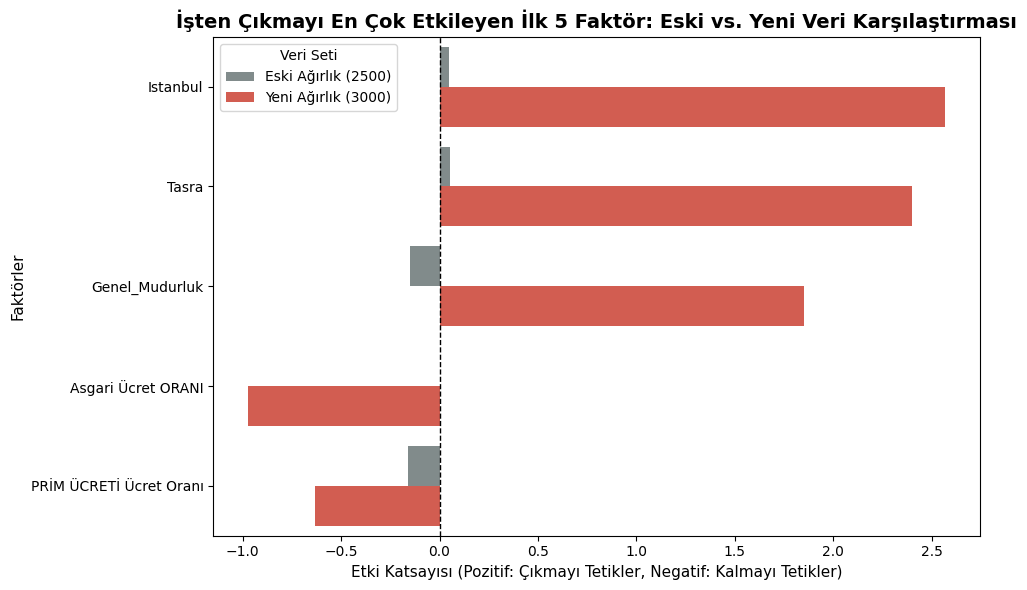


--- İLK 5 FAKTÖRÜN RAKAMSAL DEĞİŞİMİ ---
                     Faktör  Eski Ağırlık (2500)  Yeni Ağırlık (3000)
16                 Istanbul             0.046523             2.567891
17                    Tasra             0.051058             2.398161
15           Genel_Mudurluk            -0.148062             1.850627
22       Asgari Ücret ORANI             0.000172            -0.972263
26  PRİM ÜCRETİ Ücret Oranı            -0.159803            -0.630987


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# ==========================================
# 1. DOSYA YOLLARINI BURAYA GİR
# ==========================================
eski_dosya_yolu = r"C:\Users\enesa\Downloads\22nisanverileri.xlsx"
yeni_dosya_yolu = r"C:\Users\enesa\Downloads\3binlikveri.xlsx"

# ==========================================
# 2. MODEL EĞİTME VE AĞIRLIK BULMA FONKSİYONU
# ==========================================
def svm_agirliklarini_bul(dosya_yolu):
    # Veriyi yükle
    df = pd.read_excel(dosya_yolu)
    X = df.iloc[:, :27]
    y = df.iloc[:, 27]
    
    # Standartlaştırma (SVM için şart)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # SMOTE OLMADAN Saf SVM Modeli
    svm_model = SVC(kernel='linear', random_state=42)
    svm_model.fit(X_scaled, y)
    
    return X.columns, svm_model.coef_[0]

print("Eski veri (2500 satır) eğitiliyor...")
eski_faktorler, eski_agirliklar = svm_agirliklarini_bul(eski_dosya_yolu)

print("Yeni veri (3000 satır) eğitiliyor...")
_, yeni_agirliklar = svm_agirliklarini_bul(yeni_dosya_yolu)

# ==========================================
# 3. VERİLERİ KARŞILAŞTIRMA İÇİN HAZIRLAMA
# ==========================================
# Tüm faktörleri ve ağırlıklarını bir tabloya alalım
karsilastirma_df = pd.DataFrame({
    'Faktör': eski_faktorler,
    'Eski Ağırlık (2500)': eski_agirliklar,
    'Yeni Ağırlık (3000)': yeni_agirliklar
})

# Yeni verilere göre en çok etki eden (mutlak değerce en büyük) ilk 5 faktörü bulalım
karsilastirma_df['Yeni_Mutlak_Etki'] = karsilastirma_df['Yeni Ağırlık (3000)'].abs()
ilk_5_df = karsilastirma_df.sort_values(by='Yeni_Mutlak_Etki', ascending=False).head(5)

# Grafik çizimi için veriyi uzun formata (melt) çevirelim
grafik_verisi = ilk_5_df.melt(id_vars='Faktör', 
                              value_vars=['Eski Ağırlık (2500)', 'Yeni Ağırlık (3000)'],
                              var_name='Veri Seti', 
                              value_name='Etki Gücü')

# ==========================================
# 4. KARŞILAŞTIRMALI GRAFİK ÇİZİMİ
# ==========================================
plt.figure(figsize=(10, 6))

# Yan yana bar grafiği
sns.barplot(data=grafik_verisi, x='Etki Gücü', y='Faktör', hue='Veri Seti', palette=['#7F8C8D', '#E74C3C'])

# Eksen ve başlık ayarları
plt.title('İşten Çıkmayı En Çok Etkileyen İlk 5 Faktör: Eski vs. Yeni Veri Karşılaştırması', fontsize=14, fontweight='bold')
plt.xlabel('Etki Katsayısı (Pozitif: Çıkmayı Tetikler, Negatif: Kalmayı Tetikler)', fontsize=11)
plt.ylabel('Faktörler', fontsize=11)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1) # Sıfır çizgisi (Pozitif/Negatif ayrımı için)
plt.legend(title='Veri Seti')
plt.tight_layout()

# Grafiği göster
plt.show()

# Sayısal farkları konsola yazdır
print("\n--- İLK 5 FAKTÖRÜN RAKAMSAL DEĞİŞİMİ ---")
print(ilk_5_df[['Faktör', 'Eski Ağırlık (2500)', 'Yeni Ağırlık (3000)']])

Model eğitiliyor ve en iyi parametreler aranıyor... (Bu biraz sürebilir)
Bulunan En İyi Parametre: {'svm__C': 10}

Güncellenmiş Doğruluk Oranı: 79.53%
Yeni Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.88      0.81      0.85       408
           1       0.64      0.75      0.70       183

    accuracy                           0.80       591
   macro avg       0.76      0.78      0.77       591
weighted avg       0.81      0.80      0.80       591



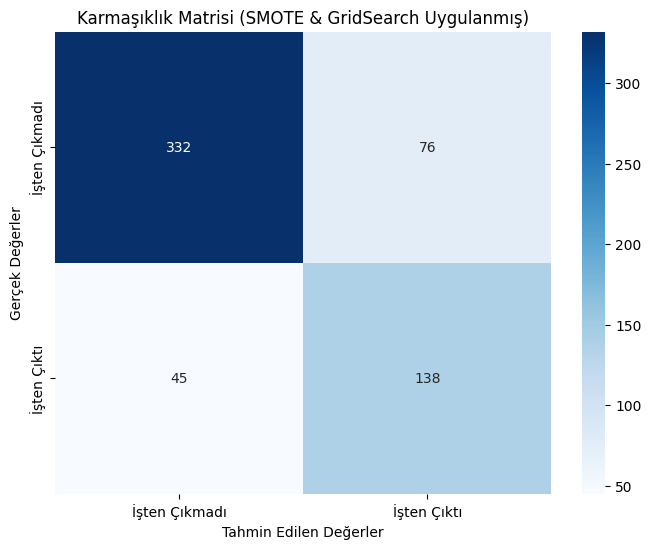

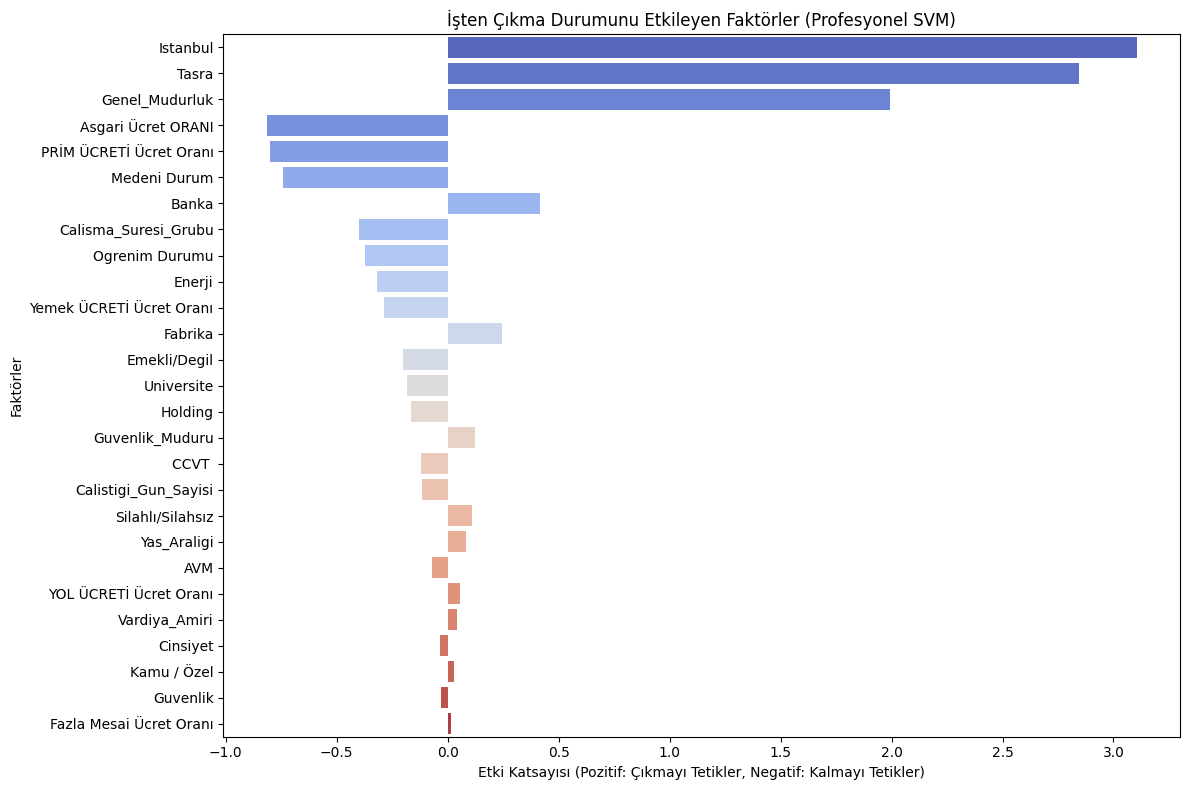

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline # Normal Pipeline yerine imblearn pipeline kullanıyoruz (Veri sızıntısını önler)

# 1. Veriyi Yükleme (Dosya yolunu kendi bilgisayarına göre güncelle)
df = pd.read_excel(r"C:\Users\enesa\Downloads\3binlikveri.xlsx")

# Özellikler ve Hedef
X = df.iloc[:, :27]
y = df.iloc[:, 27]
feature_names = X.columns

# 2. Katmanlı Bölme (Stratify): Test ve eğitim setlerindeki işten çıkma oranının aynı kalmasını sağlar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Profesyonel Pipeline Kurulumu
# İşlem sırası: Önce veriyi standartlaştır -> Sonra az olan sınıfı SMOTE ile çoğalt -> Sonra SVM'i eğit
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(kernel='linear', random_state=42))
])

# 4. Hiperparametre Optimizasyonu (Grid Search)
# SVM'in 'C' parametresi için en iyi değeri arıyoruz. (Bu işlem bilgisayarı biraz daha yoracaktır, hoca haklı!)
param_grid = {
    'svm__C': [0.1, 1, 10] # En iyi esneklik ayarını bulması için 3 farklı senaryo deneyecek
}

# Modeli 5-Fold Cross Validation ile eğitiyoruz (scoring='f1' ile azınlık sınıfı yakalamaya odaklanıyoruz)
print("Model eğitiliyor ve en iyi parametreler aranıyor... (Bu biraz sürebilir)")
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Bulunan En İyi Parametre: {grid_search.best_params_}")

# 5. En İyi Model ile Tahmin ve Raporlama
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nGüncellenmiş Doğruluk Oranı: {accuracy * 100:.2f}%")
print("Yeni Sınıflandırma Raporu:\n", classification_report(y_test, y_pred))

# Grafik 1: Karmaşıklık Matrisi
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['İşten Çıkmadı', 'İşten Çıktı'], 
            yticklabels=['İşten Çıkmadı', 'İşten Çıktı'])
plt.title('Karmaşıklık Matrisi (SMOTE & GridSearch Uygulanmış)')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilen Değerler')
plt.show()

# Grafik 2: Özellik Önem Dereceleri (Pipeline içindeki SVM modelinden ağırlıkları çekiyoruz)
importances = best_model.named_steps['svm'].coef_[0]
feature_importance_df = pd.DataFrame({'Faktör': feature_names, 'Etki (Ağırlık)': importances})

feature_importance_df['Mutlak_Etki'] = feature_importance_df['Etki (Ağırlık)'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Mutlak_Etki', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Etki (Ağırlık)', y='Faktör', data=feature_importance_df, hue='Faktör', palette='coolwarm', legend=False)
plt.title('İşten Çıkma Durumunu Etkileyen Faktörler (Profesyonel SVM)')
plt.xlabel('Etki Katsayısı (Pozitif: Çıkmayı Tetikler, Negatif: Kalmayı Tetikler)')
plt.ylabel('Faktörler')
plt.tight_layout()
plt.show()